# Does more data always give better results?

### _A case study on the Indiana University Chest X-ray dataset using MedGamma_

8DM60 Multimodal AI in Biomedicine Project work - Group 11

_Chris Smeets (1845403), Ian Fengler (1895265), Boran Biemans (1535293), Wessel Nuijten (1879480), Jop van den Brand (1881914)_

This notebook is based on the starter notebook provided for the 8DM60 Multimodal AI in Biomedicine course. In this notebook, we explore the effect of adding different views of chest X-rays to multimodal AI models and comparing the model performance through multiple experiments.

## Table of contents

1. [Overview and prerequisites](#1-overview-and-prerequisites)
2. [Settings](#2-settings)
3. [Download and prepare the dataset](#3-download-and-prepare-the-dataset)
4. [Load MedGemma](#4-load-medgemma)
5. [Generate and inspect a report](#5-generate-and-inspect-a-report)
6. [Results and metrics](#6-results-and-metrics)


## 1. Overview and prerequisites

Use one of the following two compute options:

- **TU/e HPC:** For this course, we provide students access to one of our high performance computing (HPC) servers, which is equipped with NVIDIA 2080ti GPUs. More information will be given during the first BZ.
- **Google Colab:** choose **Runtime → Change runtime type → GPU**. Colab storage is temporary, so downloaded data is lost when the runtime is reset.

Run the installation cell once. **If it installs or changes packages, restart the Jupyter kernel or Colab runtime before continuing so the new packages take effect.** Then run the remaining cells section by section.

Before loading the model, visit the [MedGemma model page](https://huggingface.co/google/medgemma-4b-it) while signed in and accept the Health AI Developer Foundations terms. Also create a read token in your [Hugging Face settings](https://huggingface.co/settings/tokens). In Colab, you may store it as an `HF_TOKEN` secret and grant the notebook access; otherwise, a later cell opens the appropriate login interface.

The workbook uses the following libraries:

- **PyTorch** runs model inference on the GPU.
- **torchvision** supplies image transforms used by the model processor.
- **Transformers** provides MedGemma, its processor, generation, and quantized loading.
- **Hugging Face Hub** authenticates access to the gated model and caches its files.
- **Accelerate** places the model on the GPU, without requiring CPU memory load first.
- **bitsandbytes** stores the frozen base model in 4-bit form so it fits in 11 GB.
- **KaggleHub** downloads and caches the X-Ray dataset.
- **pandas** prepares report and projection metadata.
- **NumPy**, **Pillow**, **Matplotlib**, and **scikit-learn** support data handling, image loading, plots, and metrics.

The course environment installs the complete pinned stack. Colab keeps its preinstalled PyTorch, CUDA, and scientific Python stack and installs only the model-specific packages. This avoids replacing packages maintained as one compatible Colab runtime image. The environment cell reports the resulting versions for reproducibility.


In [1]:
from importlib.util import find_spec
import subprocess
import sys
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

print(f"Python {sys.version.split()[0]}")

# A direct dependencies are pinned to a specific versionso so all students
# work with the same model and preprocessing behavior.
model_requirements = [
    "transformers==4.57.6",
    "huggingface_hub==0.36.0",
    "accelerate==1.6.0",
    "bitsandbytes==0.49.2",
    "kagglehub==1.0.2",
    "num2words==0.5.14",
    "ipywidgets==8.1.8",
    "sentencepiece==0.2.1",
]

IN_COLAB = (
    find_spec("google") is not None
    and find_spec("google.colab") is not None
)

if IN_COLAB:
    # Keep Colab's matched PyTorch/CUDA and scientific Python packages.
    requirements = model_requirements
    print("Colab detected: keeping its preinstalled compute stack.")
else:
    requirements = [
        "torch==2.13.0",
        "torchvision==0.28.0",
        "pandas==3.0.3",
        "Pillow==12.3.0",
        "matplotlib==3.11.1",
        "scikit-learn==1.9.0",
        "numpy==2.5.1",
        *model_requirements,
    ]

# Install into the environment used by this notebook kernel.
subprocess.check_call(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
        "--quiet",
        "--upgrade",
        "--disable-pip-version-check",
        *requirements,
    ]
)


Python 3.12.3


0

In [2]:
%matplotlib inline

# Standard-library utilities handle paths, disk space, and reporting.
from importlib.metadata import version
from pathlib import Path
from shutil import disk_usage
import sys
import textwrap
import warnings

# bitsandbytes currently triggers this harmless PyTorch compatibility warning.
warnings.filterwarnings(
    "ignore",
    message=r"_check_is_size will be removed in a future PyTorch release.*",
    category=FutureWarning,
)

# Scientific Python libraries handle data, images, plots, and projections.
import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from PIL import Image

# Transformers supplies the multimodal processor, model, and quantization config.
from transformers import (
    AutoModelForImageTextToText,
    AutoProcessor,
    BitsAndBytesConfig,
)

if not torch.cuda.is_available():
    raise RuntimeError(
        "This workbook requires a CUDA-enabled PyTorch environment. "
        "Select the course GPU kernel, or choose a GPU runtime in Colab."
    )

# Print the library versions (for debugging purposes)
print(f"Python: {sys.version.split()[0]}")
for distribution in (
    "torch", "torchvision", "transformers", "huggingface_hub",
    "accelerate",
    "bitsandbytes", "kagglehub", "pandas", "Pillow",
    "matplotlib", "scikit-learn", "numpy", "num2words",
    "ipywidgets",
):
    print(f"{distribution}: {version(distribution)}")
print(f"GPU: {torch.cuda.get_device_name(0)}")


Python: 3.12.3
torch: 2.13.0
torchvision: 0.28.0
transformers: 4.57.6
huggingface_hub: 0.36.0
accelerate: 1.6.0
bitsandbytes: 0.49.2
kagglehub: 1.0.2
pandas: 3.0.3
Pillow: 12.3.0
matplotlib: 3.11.1
scikit-learn: 1.9.0
numpy: 2.5.1
num2words: 0.5.14
ipywidgets: 8.1.5
GPU: NVIDIA GeForce RTX 2080 Ti


## 2. Settings

The settings below are the main controls you may want to change:

- `PROMPT` is used for zero-shot and one-shot report generation. It requests the short report format used in this exercise.
- `EXAMPLE_INDEX` selects one study ID from the reproducibly sorted table; counting starts at zero.
- `MAX_NEW_TOKENS` limits generated report length. Tokens are pieces of words, not an exact word count.
- `COMPUTE_DTYPE` selects the arithmetic precision used around the 4-bit weights. FP32 is slower but works consistently on the course RTX 2080 Ti and Colab GPUs; keeping it fixed also makes results easier to compare.
Changing an early setting requires rerunning the cells that depend on it.


In [3]:
# General model and reproducibility settings.
SEED = 0
MODEL_ID = "google/medgemma-4b-it"
SYSTEM_PROMPT = "You are an expert radiologist."
PROMPT = (
    "Write a concise radiology report for this chest X-ray. "
    "Use Findings and Impression sections. Describe only findings "
    "supported by the image and state uncertainty when necessary."
)
COMBINED_PROMPT = (
    "Write a concise radiology report for these frontal and lateral "
    "chest X-rays of the same study. Use Findings and Impression sections. "
    "Describe only findings supported by the images and state uncertainty "
    "when necessary."
)

# Every experiment below is repeated for each of these views.
VIEWS = ("frontal", "lateral", "combined")

MAX_NEW_TOKENS = 160
COMPUTE_DTYPE = torch.float32

# Report generation settings.
EXAMPLE_INDEX = 3



## 3. Download and prepare the dataset

The [Indiana University Chest X-ray dataset](https://openi.nlm.nih.gov/faq) contains chest X-rays paired with radiology reports. The KaggleHub call downloads the complete [Kaggle mirror](https://www.kaggle.com/datasets/raddar/chest-xrays-indiana-university) into its local cache. In Colab, the cache is stored on the runtime's fast local disk and disappears when the runtime is reset.

> One report can describe several images from the same study, often frontal and lateral views. This workbook keeps only one frontal image but compares it with the study-level report. A reference statement may therefore describe information that is not visible in the supplied image.

In [4]:
# Check if there is sufficient storage space for the dataset, model weights, and temporary files.
free_disk_gb = disk_usage(Path.home()).free / 2**30
print(f"Available disk space: {free_disk_gb:.1f} GB")
if free_disk_gb < 35:
    raise RuntimeError(
        "At least 35 GB of free disk space is required."
    )

# KaggleHub reuses its local cache after the first 14.2 GB download.
DATASET_ID = "raddar/chest-xrays-indiana-university"
dataset_root = Path(kagglehub.dataset_download(DATASET_ID))
print(f"Dataset directory: {dataset_root}")

Available disk space: 165.3 GB
Dataset directory: /home/20223636/.cache/kagglehub/datasets/raddar/chest-xrays-indiana-university/versions/2


In [5]:
reports = pd.read_csv(dataset_root / "indiana_reports.csv")
projections = pd.read_csv(dataset_root / "indiana_projections.csv")
image_dir = dataset_root / "images" / "images_normalized"

# Replace missing report sections with empty text, strip leading and trailing whitespace.
for column in ("findings", "impression"):
    reports[column] = reports[column].fillna("").str.strip()


def first_of_projection(df, projection):
    """Deterministically select one image per study for the given projection."""
    return (
        df[df["projection"].str.lower().eq(projection)]
        .sort_values(["uid", "filename"])
        .drop_duplicates("uid")
    )


frontals = first_of_projection(projections, "frontal")
laterals = first_of_projection(projections, "lateral")

combined = (
    frontals[["uid", "filename"]]
    .rename(columns={"filename": "frontal_filename"})
    .merge(
        laterals[["uid", "filename"]].rename(columns={"filename": "lateral_filename"}),
        on="uid",
        how="inner",
        validate="one_to_one",
    )
)


def prepare(images, filename_columns):
    """Join reports with images, drop empty reports, attach absolute image paths."""
    studies = reports.merge(images, on="uid", validate="one_to_one")
    studies = (
        studies[studies["findings"].ne("") | studies["impression"].ne("")]
        .sort_values("uid")
        .reset_index(drop=True)
    )
    for filename_col, path_col in filename_columns.items():
        studies[path_col] = studies[filename_col].map(image_dir.joinpath)
    return studies


studies_f = prepare(frontals, {"filename": "image_path"})
studies_l = prepare(laterals, {"filename": "image_path"})
studies_c = prepare(
    combined,
    {
        "frontal_filename": "frontal_image_path",
        "lateral_filename": "lateral_image_path",
    },
)

print(f"Prepared {len(studies_f):,} frontal-image studies.")
print(f"Prepared {len(studies_l):,} lateral-image studies.")
print(f"Prepared {len(studies_c):,} combined-image studies.")

# Look up each view's study table by name.
studies_by_view = {
    "frontal": studies_f,
    "lateral": studies_l,
    "combined": studies_c,
}

Prepared 3,666 frontal-image studies.
Prepared 3,536 lateral-image studies.
Prepared 3,376 combined-image studies.


In [6]:
def format_reference(row):
    """Combine findings and impression sections of a report."""
    sections = []
    if row["findings"]:
        sections.append(f"Findings\n{row['findings']}")
    if row["impression"]:
        sections.append(f"Impression\n{row['impression']}")
    return "\n\n".join(sections)


def load_xray(path):
    """Load a scan as RGB image (RGB format is expected by MedGemma)."""
    with Image.open(path) as opened_image:
        return opened_image.convert("RGB")


# Image columns and prompt per view; the combined view gives MedGemma both images.
IMAGE_COLUMNS = {
    "frontal": ["image_path"],
    "lateral": ["image_path"],
    "combined": ["frontal_image_path", "lateral_image_path"],
}
PROMPTS = {"frontal": PROMPT, "lateral": PROMPT, "combined": COMBINED_PROMPT}


def load_study_images(row, view):
    """Load all images of one study for the given view."""
    return [load_xray(row[column]) for column in IMAGE_COLUMNS[view]]


def studies_for_uids(view, uids):
    """Look up the given studies, in the given order, in one view's table."""
    return studies_by_view[view].set_index("uid").loc[list(uids)].reset_index()


# Select the example from the combined table so that every view shows the same
# study (studies with both projections also appear in the other two tables).
if not 0 <= EXAMPLE_INDEX < len(studies_c):
    raise IndexError(
        f"EXAMPLE_INDEX must be between 0 and {len(studies_c) - 1}."
    )

example_uid = studies_c.iloc[EXAMPLE_INDEX]["uid"]
examples = {}
for view in VIEWS:
    view_study = studies_for_uids(view, [example_uid]).iloc[0]
    examples[view] = {
        "images": load_study_images(view_study, view),
        "reference": format_reference(view_study),
    }
reference_report = examples["frontal"]["reference"]

print(f"Selected study {example_uid} for all views.")

Selected study 4 for all views.


## 4. Load MedGemma

[MedGemma 4B Instruct](https://huggingface.co/google/medgemma-4b-it) is a generative medical vision-language model based on Gemma 3. Its vision encoder was pretrained on several kinds of medical imagery, including chest X-rays. See Sellergren et al. (2025), [*MedGemma Technical Report*](https://arxiv.org/abs/2507.05201).

Gemma 3 converts each image to a fixed 896×896 encoder input. We retain that native resolution and for speed and simplicity we disable optional **pan-and-scan**, which adds additional local crops to the input.

To reduce GPU memory use, we load the model with its weights quantized to 4 bit NF4 format. The published MedGemma examples use BF16 computation, but the RTX 2080 Ti used in the course does not support BF16 natively, and the GPU provided by Colab may vary. On the RTX 2080 Ti, FP16 can become numerically unstable and cause the model to generate empty responses. We therefore use FP32 computation together with the quantized weights in both environments. This is slower but a lot more reliable. For reference, the numerical formats mentioned above are briefly summarized below.

| Format | Explanation |
|---|---|
| **NF4** | A 4 bit quantization format designed for normally distributed model weights that substantially reduces GPU memory use. |
| **FP16** | A 16 bit floating point format that is fast and memory efficient on many GPUs but can be numerically unstable. |
| **BF16** | A 16 bit floating point format with a wider numerical range than FP16, but it requires compatible GPU hardware for efficient native computation. |
| **FP32** | A 32 bit floating point format that uses more memory and computation but generally provides the greatest numerical stability. |

### Authorize the model download

MedGemma is a gated model, meaning that you must sign in to Hugging Face and accept the model’s terms before you can download its files. First accept its terms on the [model page](https://huggingface.co/google/medgemma-4b-it), using the same Hugging Face account that owns your read token. The next cell reuses an available token or opens the appropriate login interface for Jupyter or Colab.

In [7]:
from huggingface_hub import HfApi, hf_hub_download, login

# Reuse an existing token, including Colab's HF_TOKEN secret.
# An interactive prompt appears only when no token is available.
login(new_session=False)

# Verify the account and its access to the gated MedGemma repository.
hf_account = HfApi().whoami()["name"]
hf_hub_download(MODEL_ID, "config.json")

print(f"Authenticated with Hugging Face as {hf_account}.")


Authenticated with Hugging Face as Jopvdb.


In [8]:
# Load the processor that prepares both text and images for MedGemma.
processor = AutoProcessor.from_pretrained(MODEL_ID, use_fast=False)
# Disable creation of additional local image crops during preprocessing.
processor.image_processor.do_pan_and_scan = False

quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=COMPUTE_DTYPE,
)
model = AutoModelForImageTextToText.from_pretrained(
    MODEL_ID,
    quantization_config=quantization_config,
    dtype=COMPUTE_DTYPE,
    attn_implementation={"text_config": "eager", "vision_config": "sdpa"},
    device_map={"": 0},
    low_cpu_mem_usage=True,
).eval()

print(f"MedGemma image size: {processor.image_processor.size}")
print(f"GPU memory after loading: {torch.cuda.memory_allocated() / 2**30:.1f} GB")


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

MedGemma image size: {'height': 896, 'width': 896}
GPU memory after loading: 4.3 GB


## 5. Generate and inspect a report

MedGemma follows Gemma 3's chat format. A system message establishes the role, and the user message contains the actual image plus the editable prompt. The processor inserts visual tokens, resizes the image, and tokenizes the conversation. The generation is deterministic (`do_sample=False`) so prompt changes are easier to compare.


In [9]:
def make_messages(current_images, prompt, assistant_text=None):
    """Build one conversation with one or more images for MedGemma."""
    messages = [
        {
            "role": "system",
            "content": [{"type": "text", "text": SYSTEM_PROMPT}],
        },
        {
            "role": "user",
            "content": [
                {"type": "text", "text": prompt},
                *(
                    {"type": "image", "image": current_image}
                    for current_image in current_images
                ),
            ],
        },
    ]
    # For one-shot prompting, append the support report as context.
    if assistant_text is not None:
        messages.append(
            {
                "role": "assistant",
                "content": [{"type": "text", "text": assistant_text}],
            }
        )
    return messages


def encode_messages(messages, add_generation_prompt, **tokenizer_kwargs):
    """Apply the model's chat template and create PyTorch tensors."""
    return processor.apply_chat_template(
        messages,
        add_generation_prompt=add_generation_prompt,
        tokenize=True,
        return_dict=True,
        return_tensors="pt",
        **tokenizer_kwargs,
    )


def move_batch_to_gpu(batch, device):
    """Move a processor batch to the GPU."""
    batch = {name: value.to(device) for name, value in batch.items()}
    batch["pixel_values"] = batch["pixel_values"].to(COMPUTE_DTYPE)
    return batch


def generate_report(current_model, current_images, prompt, max_new_tokens):
    """Generate a report and decode only tokens created by the model.

    ``generate`` returns the input prompt followed by the new response, so
    the prompt length is recorded and removed before decoding.
    """
    batch = encode_messages(
        make_messages(current_images, prompt),
        add_generation_prompt=True,
    )
    batch = move_batch_to_gpu(batch, current_model.device)
    input_length = batch["input_ids"].shape[1]

    with torch.inference_mode():
        output_ids = current_model.generate(
            **batch,
            do_sample=False,
            use_cache=True,
            max_new_tokens=max_new_tokens,
        )

    new_token_ids = output_ids[0, input_length:]
    return processor.decode(
        new_token_ids,
        skip_special_tokens=True,
        clean_up_tokenization_spaces=False,
    ).strip()

### Zero-shot visual prompting

Zero-shot prompting asks MedGemma to interpret a chest X-ray without showing it an example report. The model receives only the system instruction, the reporting prompt, and the query image(s): one frontal image, one lateral image or both images for the combined view. This is the baseline against which the one-shot (`K=1`) result is compared.

The generation is deterministic and uses the same prompt, maximum output length, model, and image preprocessing as the one-shot experiment. The baseline report is later evaluated on held-out test studies using diagnostic classification F1, runtime and token consumption, separately for each view.

In [10]:
# Generate a deterministic zero-shot baseline per view.
generated_reports = {}
for view in VIEWS:
    generated_reports[view] = generate_report(
        model, examples[view]["images"], PROMPTS[view], MAX_NEW_TOKENS
    )
    print(f"Generated {view} report. Prompt: {PROMPTS[view]}")

Generated frontal report. Prompt: Write a concise radiology report for this chest X-ray. Use Findings and Impression sections. Describe only findings supported by the image and state uncertainty when necessary.
Generated lateral report. Prompt: Write a concise radiology report for this chest X-ray. Use Findings and Impression sections. Describe only findings supported by the image and state uncertainty when necessary.
Generated combined report. Prompt: Write a concise radiology report for these frontal and lateral chest X-rays of the same study. Use Findings and Impression sections. Describe only findings supported by the images and state uncertainty when necessary.


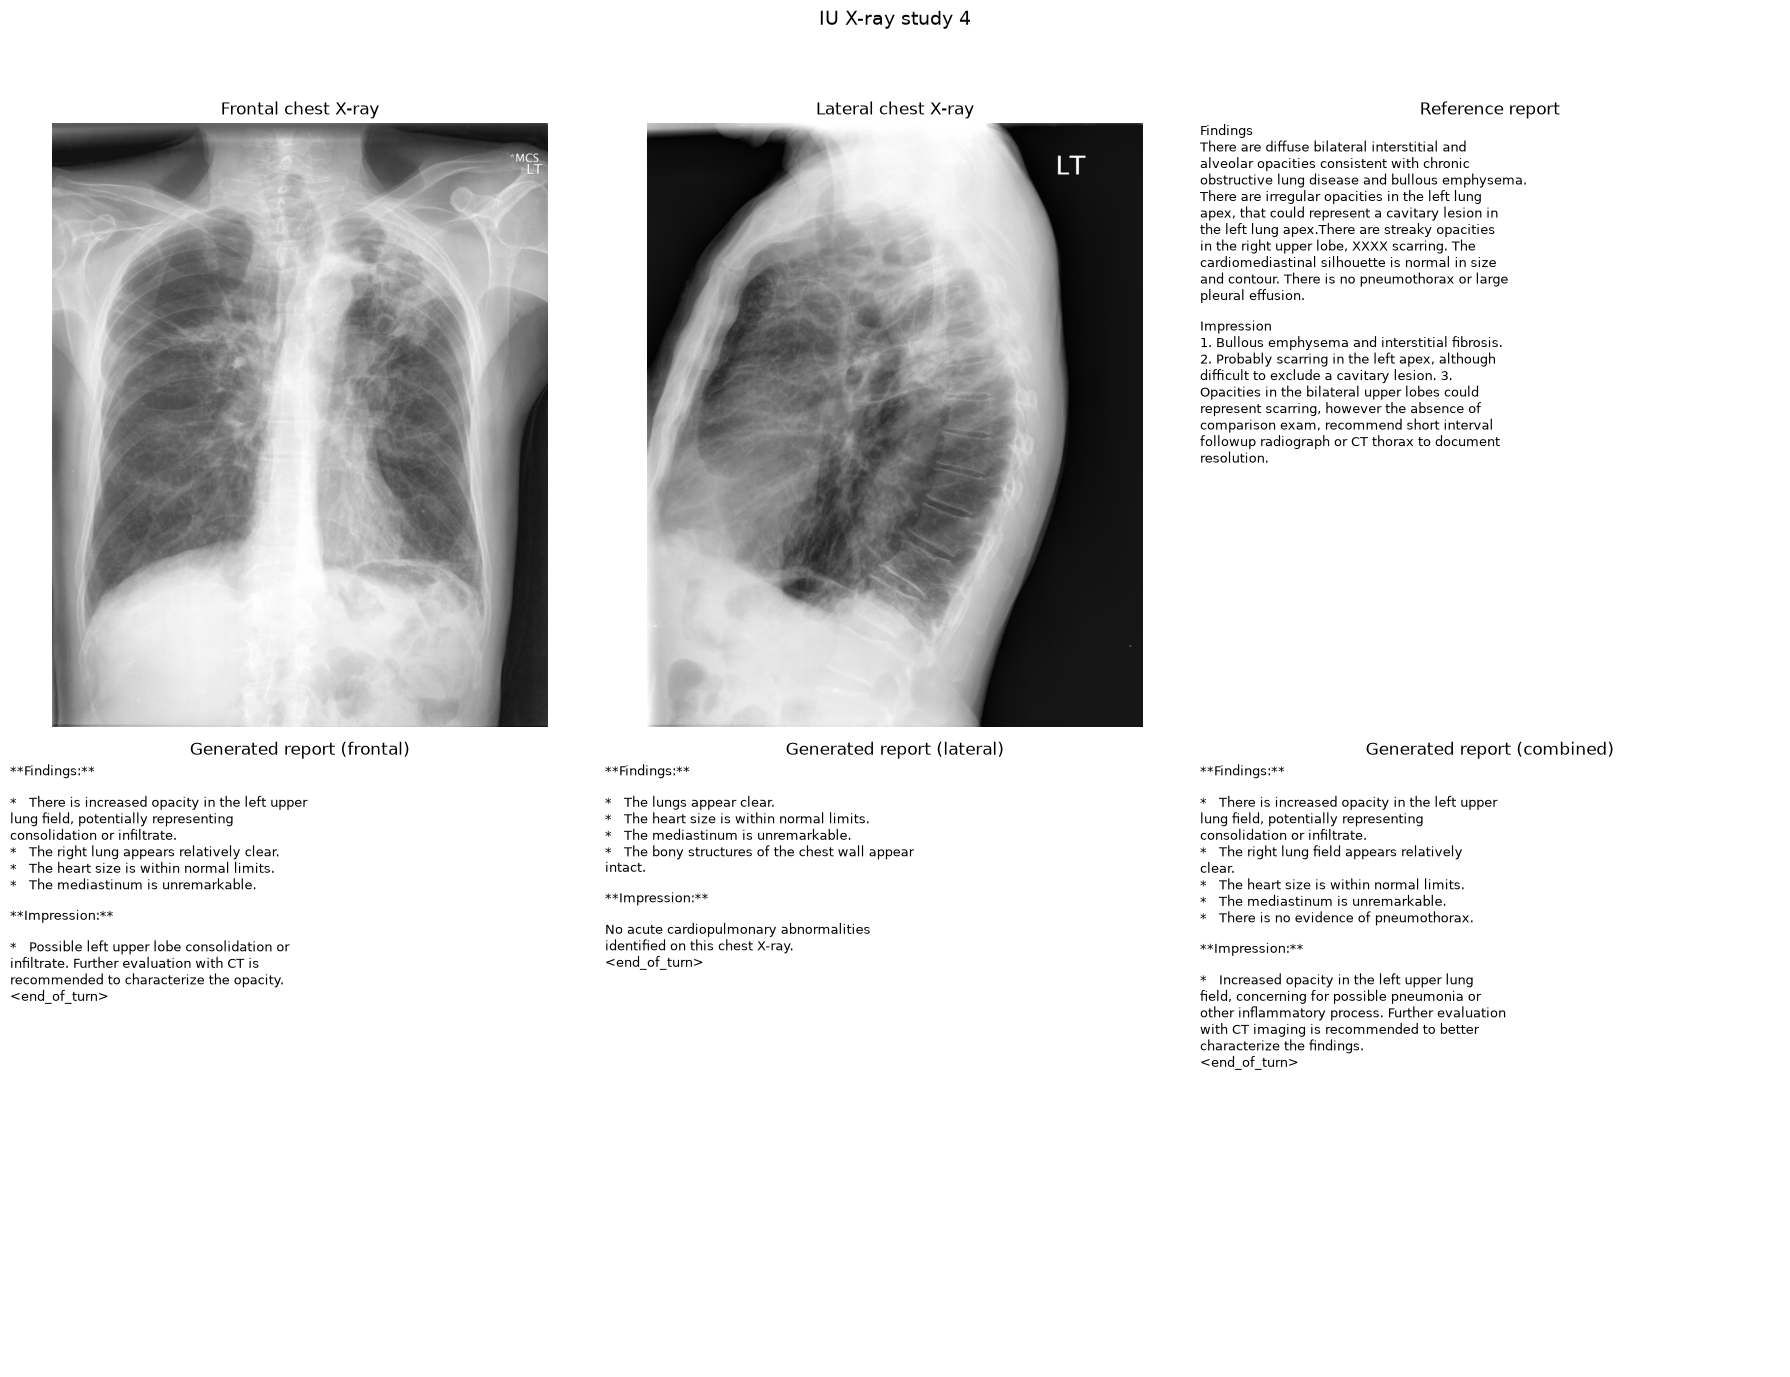

In [11]:
def wrap_report(report, width=48):
    """Wrap report lines without discarding section breaks."""
    return "\n".join(
        textwrap.fill(line, width=width) if line else ""
        for line in report.splitlines()
    )


def add_report_panel(axis, title, report, width=48):
    """Render report text in a Matplotlib axis."""
    axis.text(
        0, 1, wrap_report(report, width),
        va="top", ha="left", fontsize=9, transform=axis.transAxes,
    )
    axis.set_title(title)
    axis.axis("off")


def side_by_side(images, height=512):
    """Resize images to a common height and place them next to each other."""
    resized = [
        current_image.resize(
            (round(current_image.width * height / current_image.height), height)
        )
        for current_image in images
    ]
    canvas = Image.new("RGB", (sum(part.width for part in resized), height))
    offset = 0
    for part in resized:
        canvas.paste(part, (offset, 0))
        offset += part.width
    return canvas


# Top row: both images and the reference; bottom row: one generated report per view.
fig, axes = plt.subplots(2, 3, figsize=(18, 14))
for axis, view in zip(axes[0, :2], ("frontal", "lateral")):
    axis.imshow(examples[view]["images"][0])
    axis.set_title(f"{view.capitalize()} chest X-ray")
    axis.axis("off")
add_report_panel(axes[0, 2], "Reference report", reference_report)
for axis, view in zip(axes[1], VIEWS):
    add_report_panel(axis, f"Generated report ({view})", generated_reports[view])
fig.suptitle(f"IU X-ray study {example_uid}", fontsize=14)
plt.tight_layout(rect=(0, 0, 1, 0.95))
plt.show()

### One-shot visual prompting

One-shot prompting gives MedGemma one labelled training example before a held-out query. The example contains the chest X-ray(s) of one study and its reference report. The query comes from a separate test split, so its report is not shown to the model. For the combined view, both the example and the query contain a frontal and a lateral image.

The split is drawn from the studies that have both projections, so the frontal, lateral, and combined experiments use exactly the same support and query studies.

The experiment records prompt tokens, generated tokens, and runtime so the one-shot result can be compared with the zero-shot baseline.

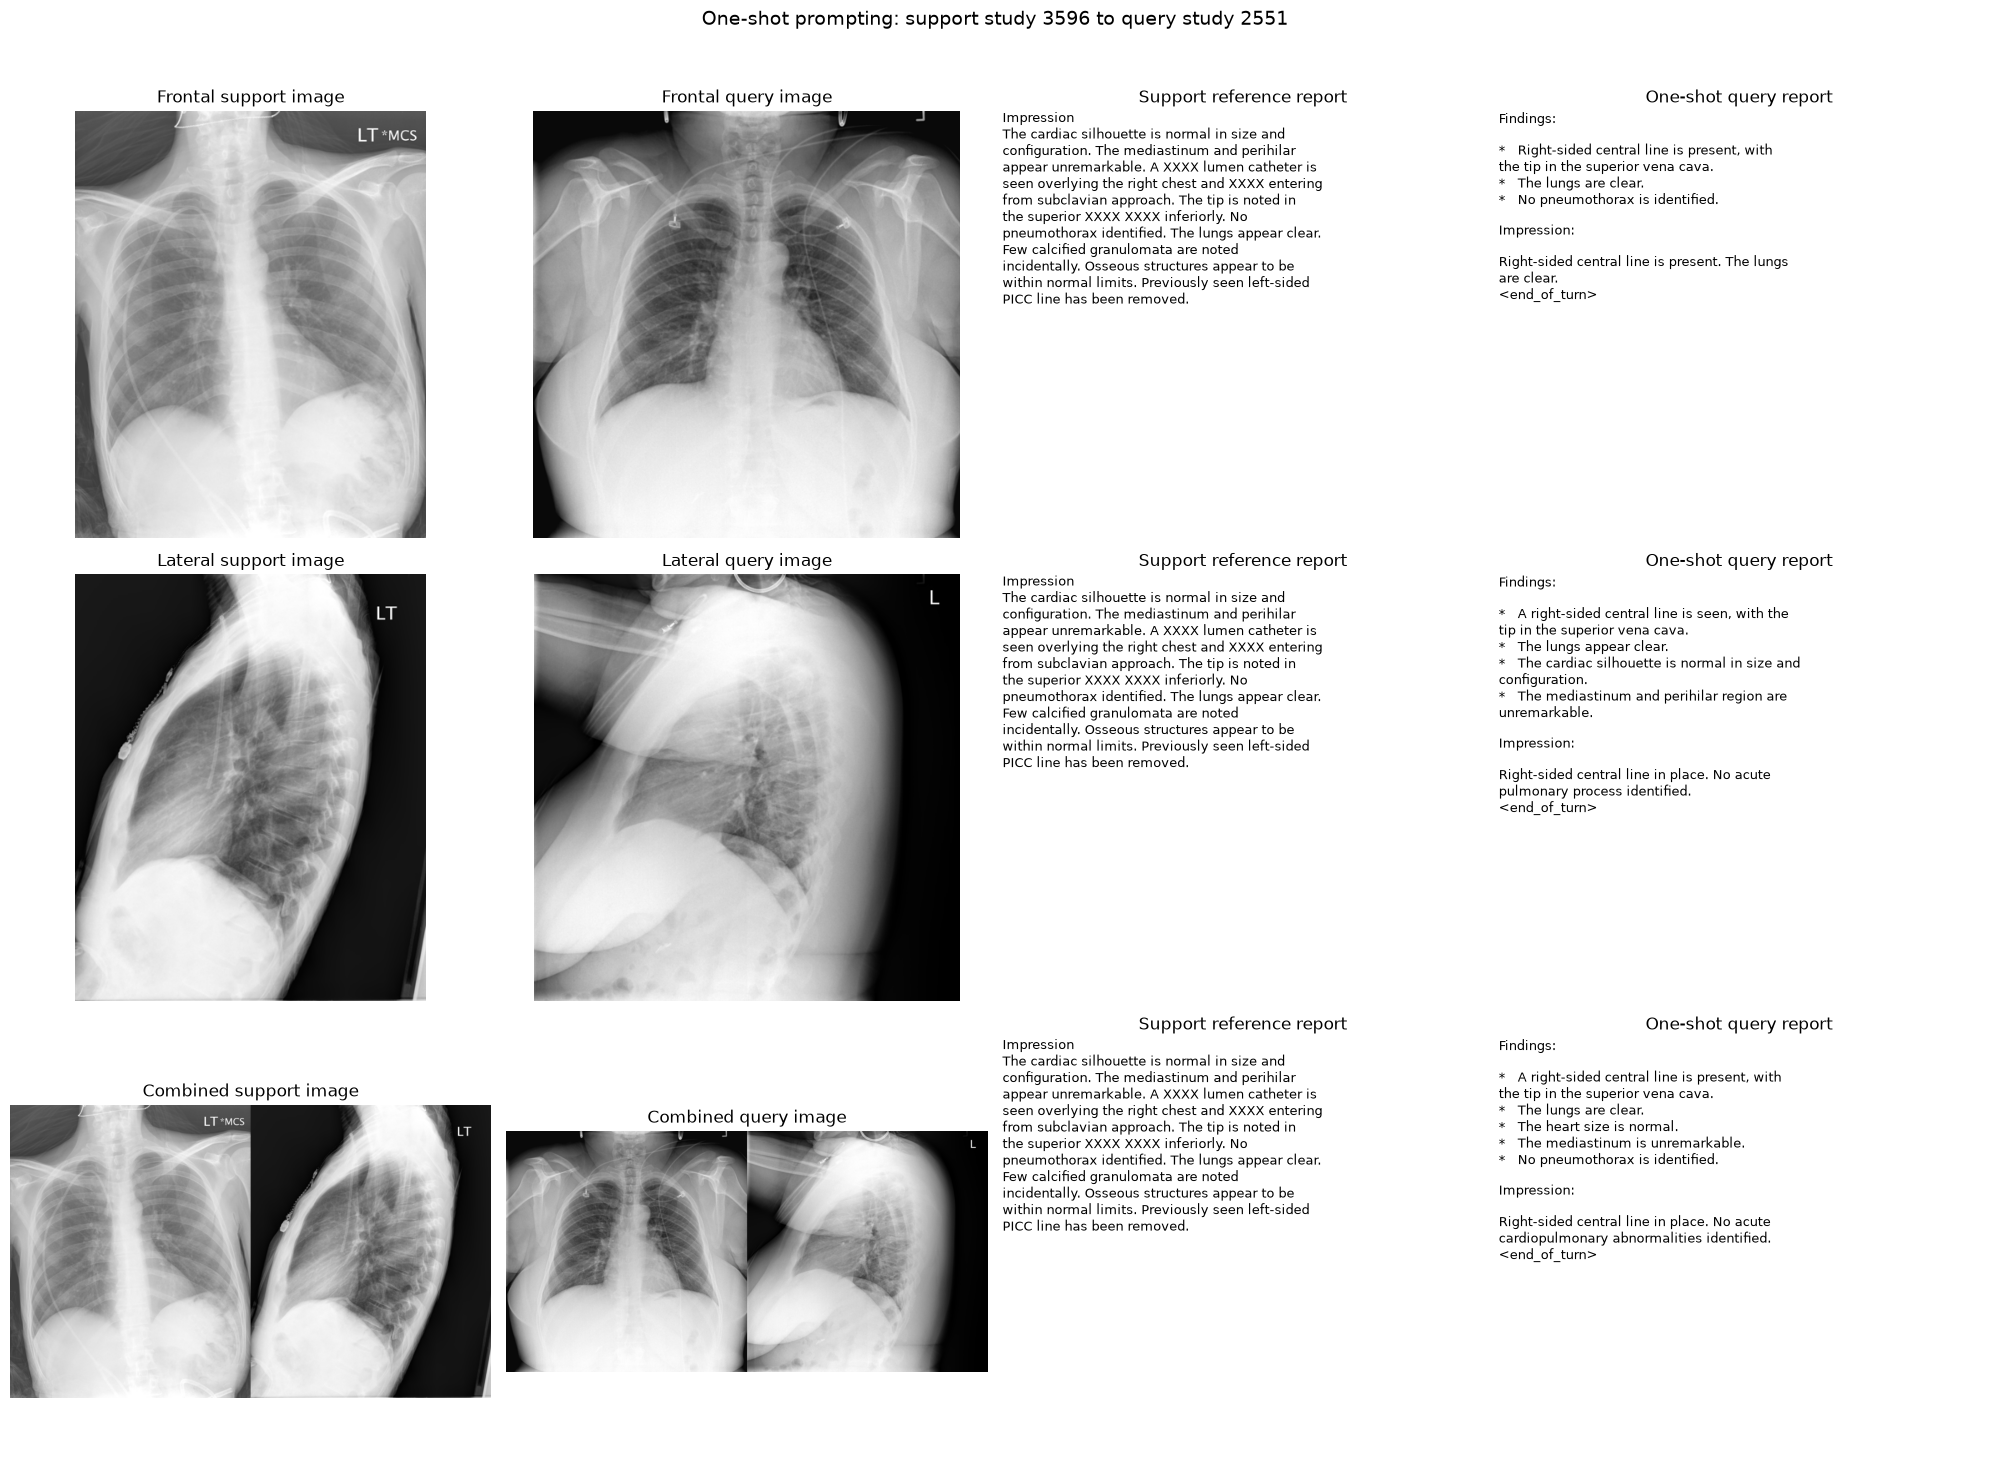

In [12]:
# Reproducible 80/10/10 study split, shared by every view.
train_uids, _, test_uids = np.split(
    studies_c["uid"].sample(frac=1, random_state=SEED).to_numpy(),
    [int(.8 * len(studies_c)), int(.9 * len(studies_c))],
)
support_uid = train_uids[0]
query_uid = test_uids[0]


def make_one_shot_messages(support_images, support_report, query_images, prompt):
    return [
        {"role": "system", "content": [{"type": "text", "text": SYSTEM_PROMPT}]},
        {"role": "user", "content": [
            {"type": "text", "text": "Use this labelled example as a guide."},
            *({"type": "image", "image": support_image}
              for support_image in support_images),
        ]},
        {"role": "assistant", "content": [{"type": "text", "text": support_report}]},
        {"role": "user", "content": [
            {"type": "text", "text": prompt},
            *({"type": "image", "image": query_image}
              for query_image in query_images),
        ]},
    ]


def generate_with_stats(messages):
    batch = move_batch_to_gpu(
        encode_messages(messages, add_generation_prompt=True), model.device
    )
    prompt_tokens = batch["input_ids"].shape[1]
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    start = __import__("time").perf_counter()
    with torch.inference_mode():
        output = model.generate(
            **batch, do_sample=False, use_cache=True,
            max_new_tokens=MAX_NEW_TOKENS,
        )
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    tokens = output[0, prompt_tokens:]
    return {
        "report": processor.decode(tokens, skip_special_tokens=True).strip(),
        "prompt_tokens": int(prompt_tokens),
        "generated_tokens": int(tokens.numel()),
        "runtime_seconds": __import__("time").perf_counter() - start,
    }


one_shot_results = {}
for view in VIEWS:
    view_pair = studies_for_uids(view, [support_uid, query_uid])
    support, query = view_pair.iloc[0], view_pair.iloc[1]
    support_images = load_study_images(support, view)
    query_images = load_study_images(query, view)
    support_report = format_reference(support)

    one_shot_results[view] = generate_with_stats(
        make_one_shot_messages(
            support_images, support_report, query_images, PROMPTS[view]
        )
    )

# Show the one-shot context visually: the model sees the support image/report first and then generates a report for the query image.
figure, axes = plt.subplots(
    len(VIEWS), 4, figsize=(20, 5 * len(VIEWS)), squeeze=False,
)
for row, view in enumerate(VIEWS):
    view_pair = studies_for_uids(view, [support_uid, query_uid])
    support, query = view_pair.iloc[0], view_pair.iloc[1]
    support_images = load_study_images(support, view)
    query_images = load_study_images(query, view)
    axes[row, 0].imshow(side_by_side(support_images))
    axes[row, 0].set_title(f"{view.capitalize()} support image")
    axes[row, 0].axis("off")
    axes[row, 1].imshow(side_by_side(query_images))
    axes[row, 1].set_title(f"{view.capitalize()} query image")
    axes[row, 1].axis("off")
    add_report_panel(
        axes[row, 2], "Support reference report", format_reference(support),
    )
    add_report_panel(
        axes[row, 3], "One-shot query report", one_shot_results[view]["report"],
    )
figure.suptitle(
    f"One-shot prompting: support study {support_uid} to query study {query_uid}",
    fontsize=14,
)
plt.tight_layout(rect=(0, 0, 1, 0.96))
plt.show()


## 6. Results and metrics

### Evaluation: zero-shot and one-shot report generation

This block generates reports for zero-shot (`K=0`) and one-shot (`K=1`) prompting on held-out studies across multiple random seeds and three input configurations: frontal, lateral, and combined views. The generated reports and their metadata are stored in `results` for the separate metrics block below.

**Evaluation design**

- Each seed defines a reproducible 80/10/10 study split.
- The first training study is used as the one-shot support example.
- The same test studies are evaluated for all views within a seed.
- Reports are mapped to `normal` or `abnormal` using the explicit phrases in `NORMAL_PHRASES`.
- The evaluation block also displays qualitative correct and incorrect examples, but does not calculate the aggregate metrics.

> **Runtime note:** this cell evaluates up to `EVALUATION_MAX_STUDIES` held-out studies per seed: `len(EVALUATION_SEEDS) × len(VIEWS) × EVALUATION_MAX_STUDIES × 2` generations. With the current settings this is `3 × 3 × 100 × 2 = 1,800` generations.

Seed 0, frontal: evaluated 50 test studies.
Seed 0, lateral: evaluated 50 test studies.
Seed 0, combined: evaluated 50 test studies.
Seed 1, frontal: evaluated 50 test studies.
Seed 1, lateral: evaluated 50 test studies.
Seed 1, combined: evaluated 50 test studies.
Seed 2, combined: evaluated 50 test studies.


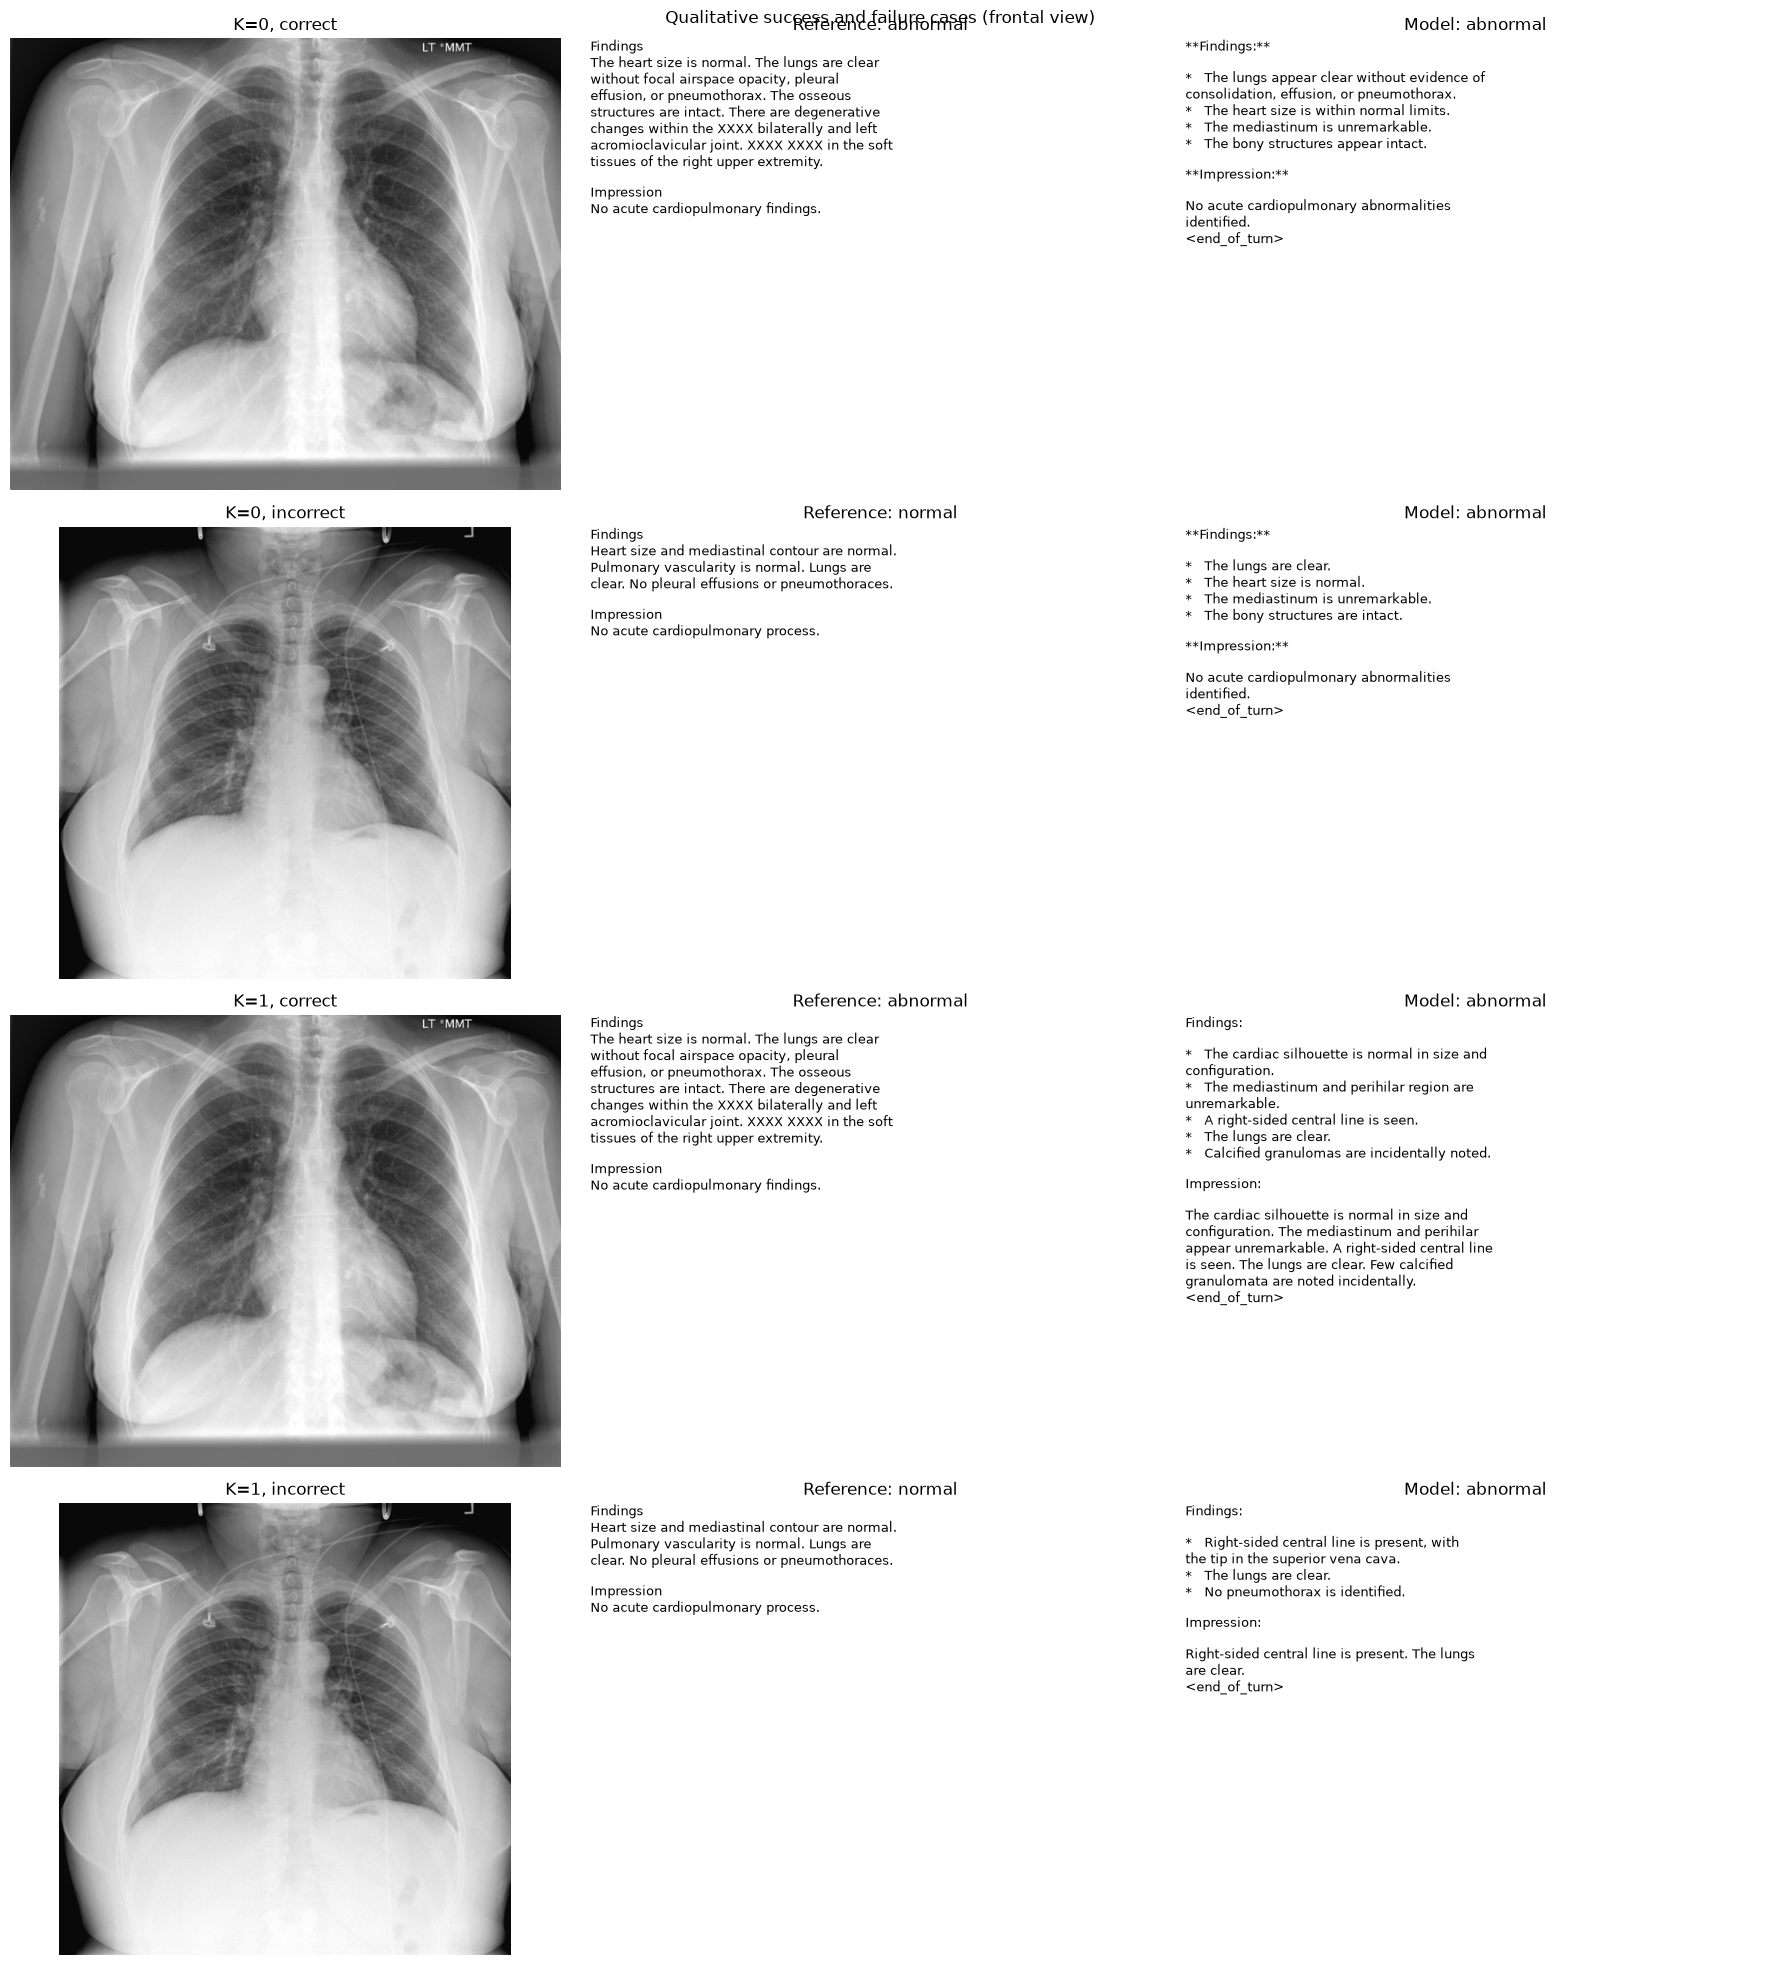

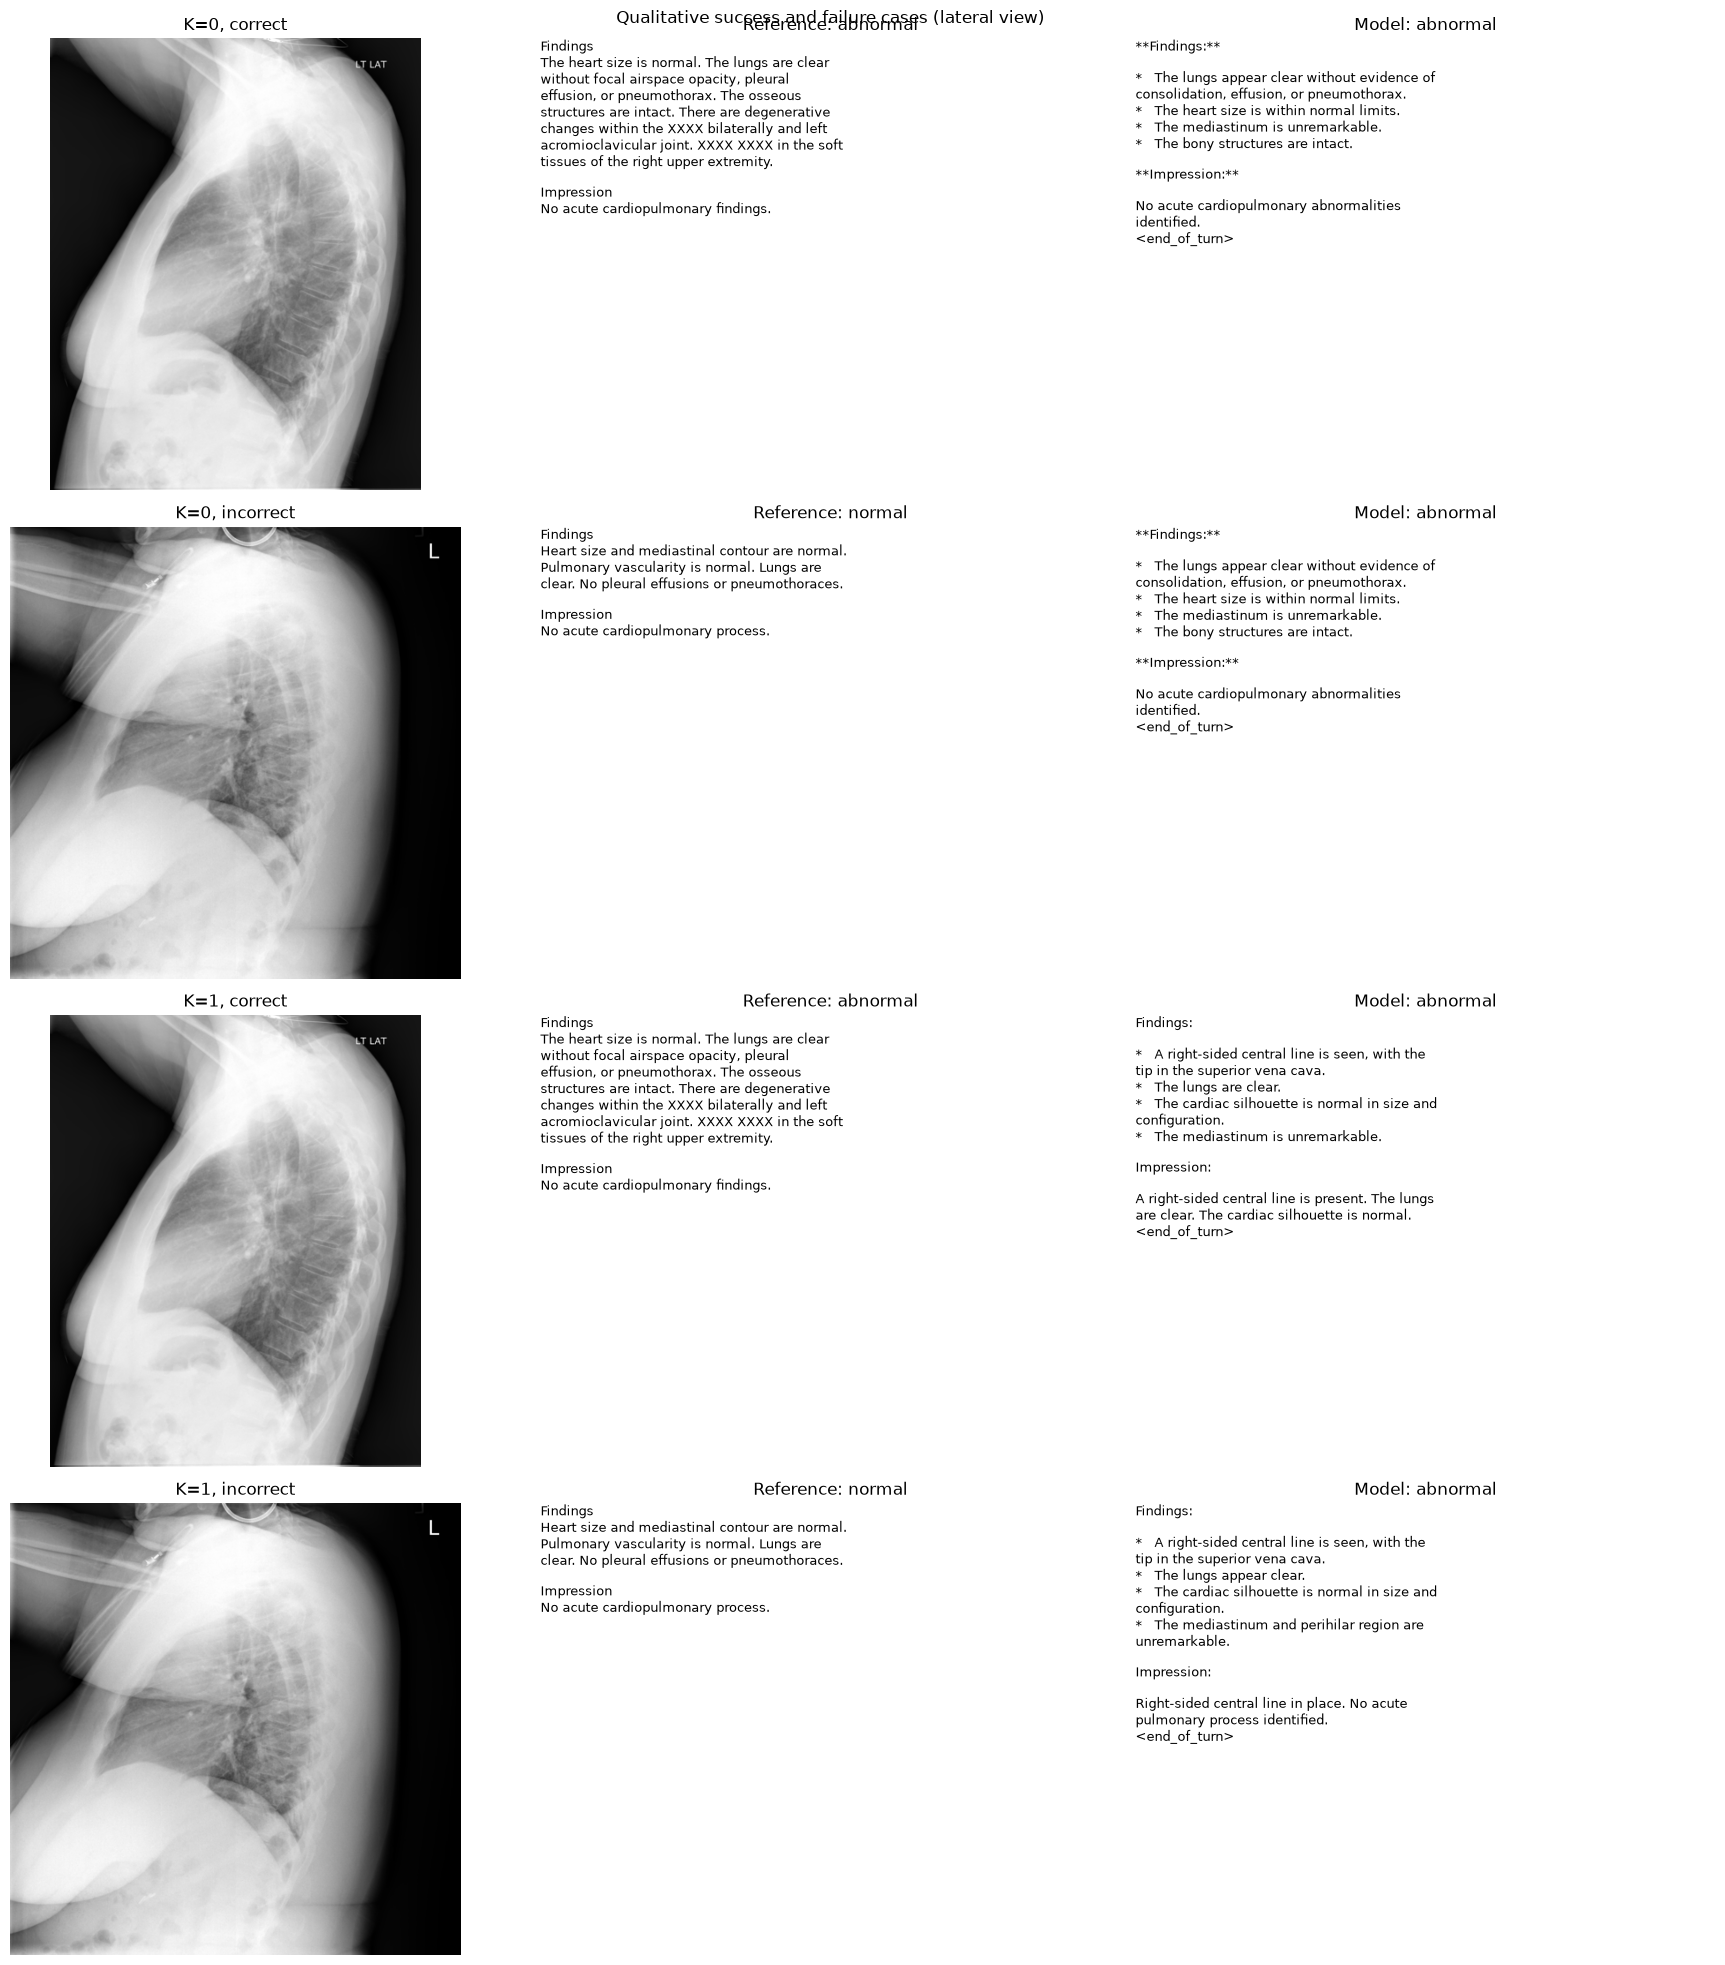

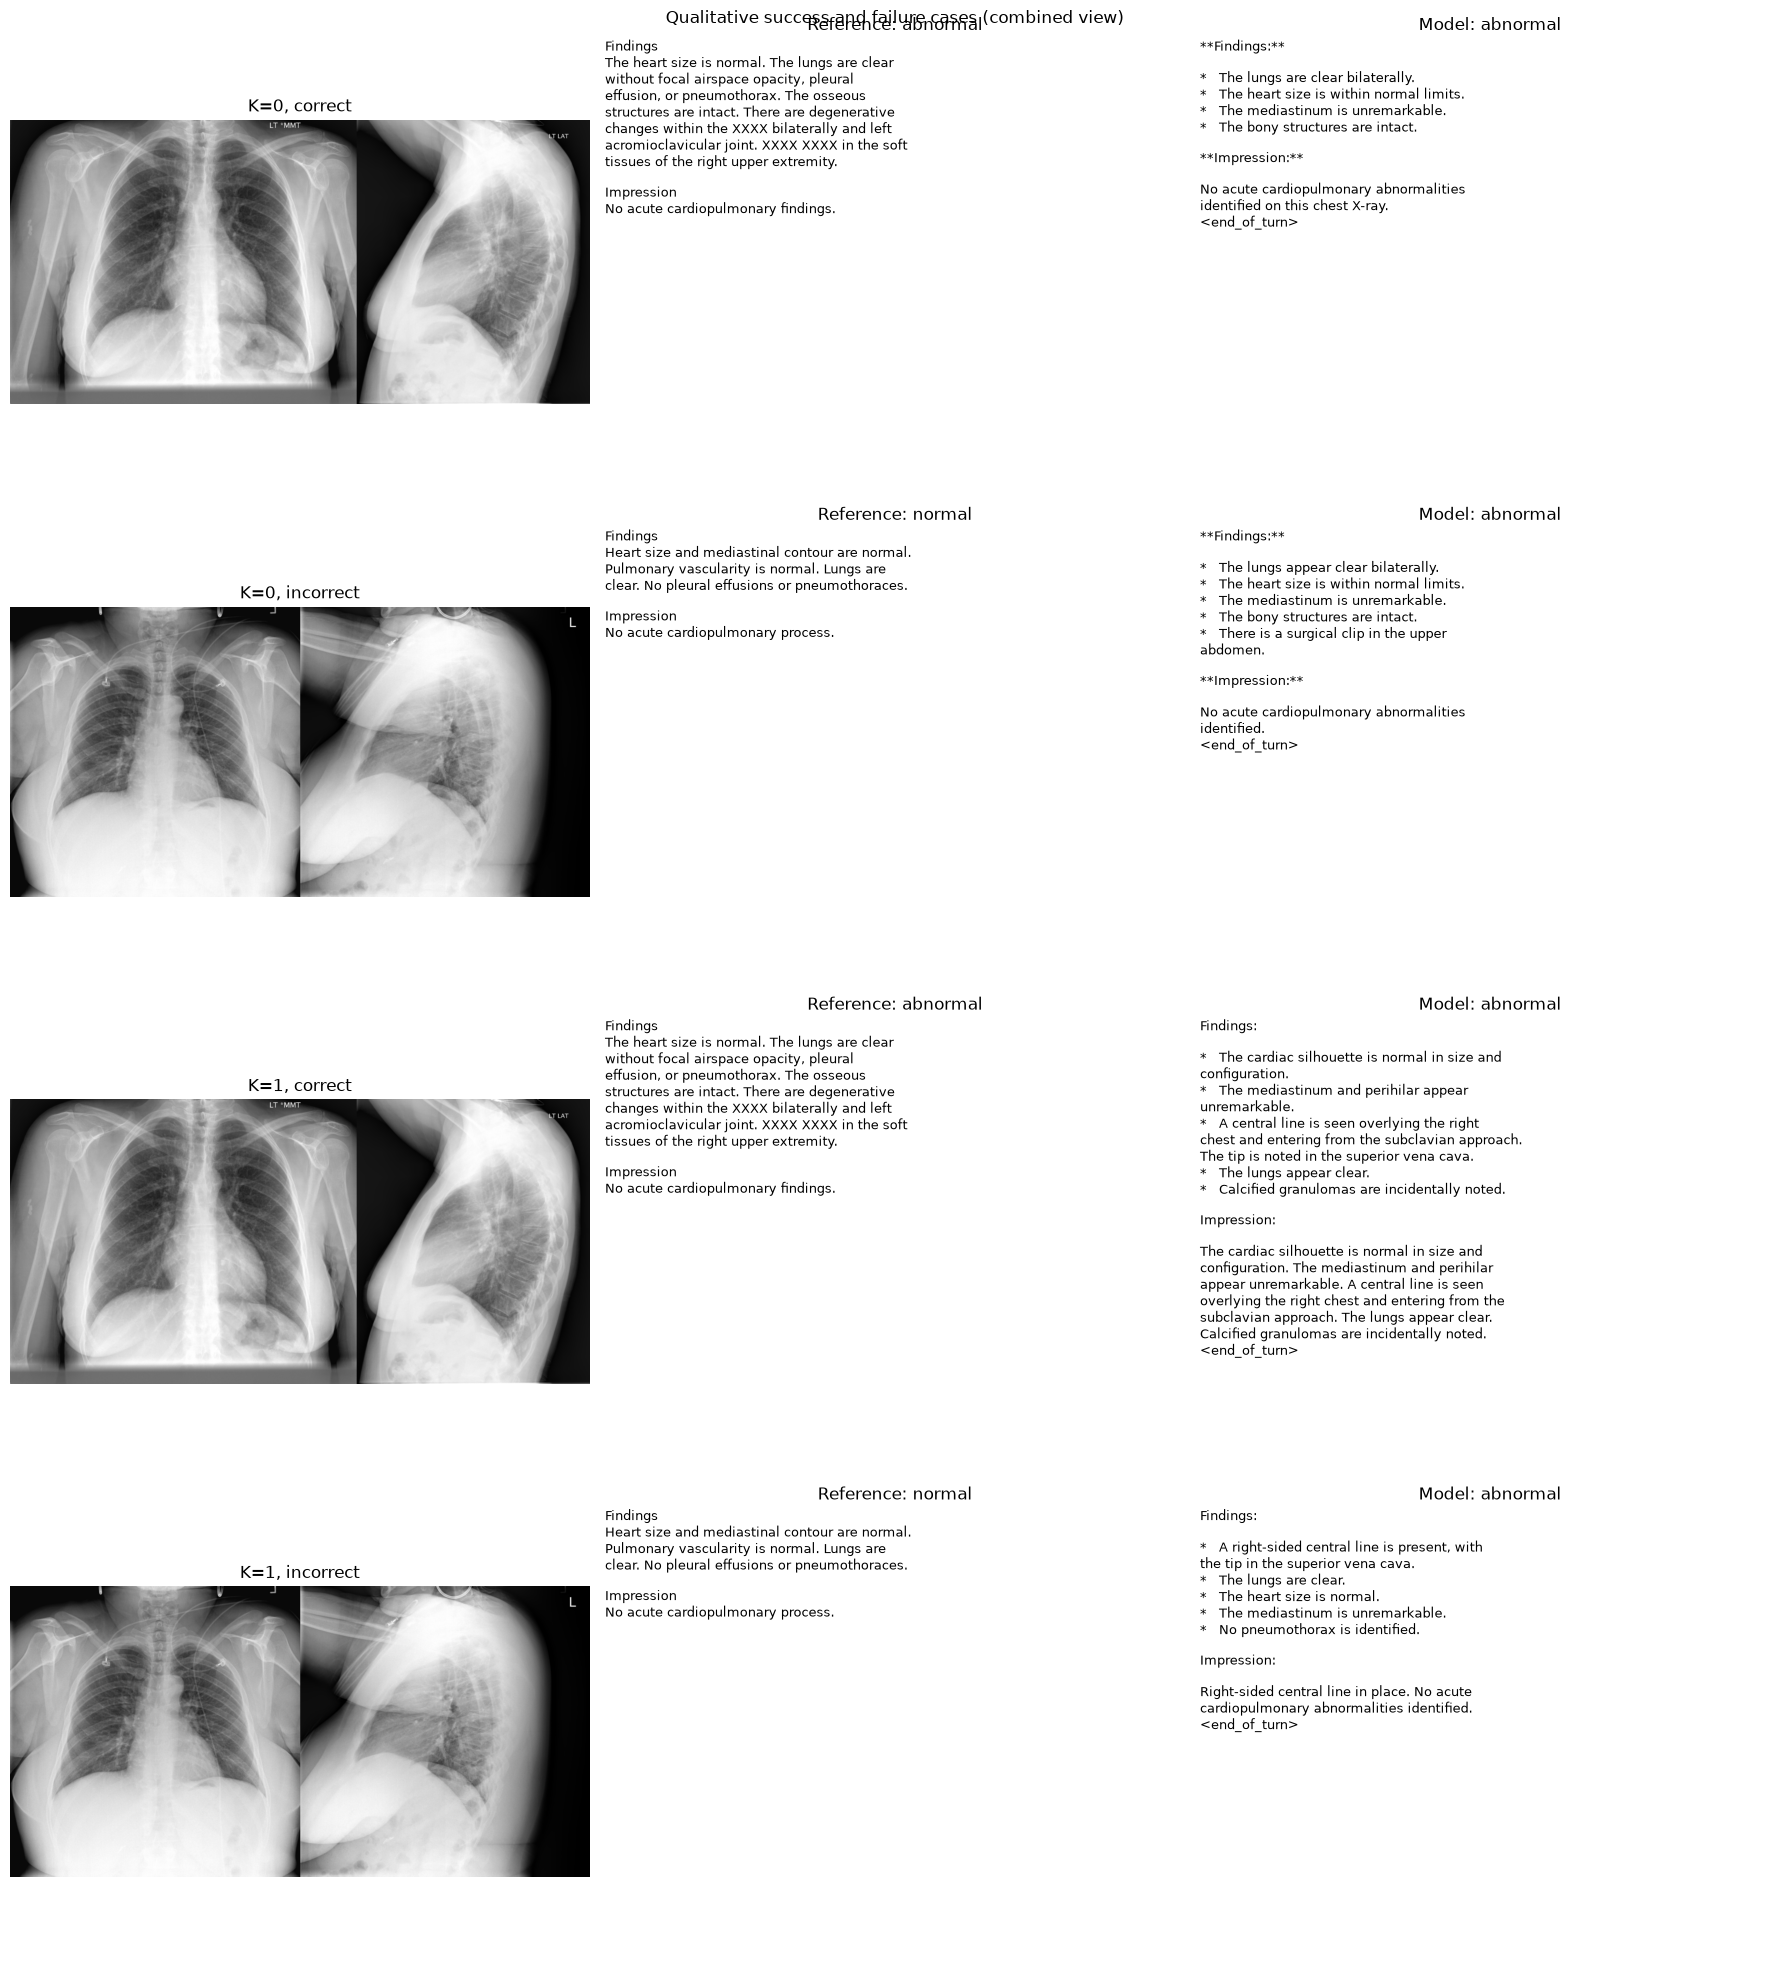

In [13]:
from sklearn.metrics import confusion_matrix, f1_score

EVALUATION_SEEDS = (0, 1, 2)
EVALUATION_MAX_STUDIES = 50
NORMAL_PHRASES = (
    "no acute cardiopulmonary abnormality",
    "no acute cardiopulmonary disease",
    "no acute cardiopulmonary process",
    "no active cardiopulmonary disease",
    "no acute disease",
    "no acute findings",
    "normal chest",
    "normal exam",
)


def classify_report(report):
    return "normal" if any(p in report.casefold() for p in NORMAL_PHRASES) else "abnormal"


rows = []
for seed in EVALUATION_SEEDS:
    train_uids, _, test_uids = np.split(
        studies_c["uid"].sample(frac=1, random_state=seed).to_numpy(),
        [int(.8 * len(studies_c)), int(.9 * len(studies_c))],
    )
    for view in VIEWS:
        support = studies_for_uids(view, train_uids[:1]).iloc[0]
        support_images = load_study_images(support, view)
        support_report = format_reference(support)
        test = studies_for_uids(view, test_uids[:EVALUATION_MAX_STUDIES])
        for _, study in test.iterrows():
            images = load_study_images(study, view)
            reference = format_reference(study)
            label = classify_report(reference)
            for k, messages in (
                (0, make_messages(images, PROMPTS[view])),
                (1, make_one_shot_messages(
                    support_images, support_report, images, PROMPTS[view]
                )),
            ):
                result = generate_with_stats(messages)
                predicted = classify_report(result["report"])
                rows.append({
                    "seed": seed, "view": view, "k": k, "uid": study["uid"],
                    "image_paths": [study[column] for column in IMAGE_COLUMNS[view]],
                    "reference_report": reference,
                    "generated_report": result["report"],
                    "reference_label": label, "predicted_label": predicted,
                    "correct": label == predicted, **result,
                })
        print(f"Seed {seed}, {view}: evaluated {len(test)} test studies.")

results = pd.DataFrame(rows)
for view in VIEWS:
    examples_to_plot = []
    for k in sorted(results["k"].unique()):
        group = results[results["view"].eq(view) & results["k"].eq(k)]
        examples_to_plot += [
            group[group["correct"].eq(correct)].iloc[0]
            for correct in (True, False)
            if group["correct"].eq(correct).any()
        ]

    if examples_to_plot:
        figure, axes = plt.subplots(
            len(examples_to_plot), 3, figsize=(18, 5 * len(examples_to_plot)),
            squeeze=False,
        )
        for row, example in enumerate(examples_to_plot):
            axes[row, 0].imshow(
                side_by_side([load_xray(path) for path in example["image_paths"]])
            )
            axes[row, 0].set_title(
                f"K={int(example['k'])}, "
                f"{'correct' if example['correct'] else 'incorrect'}"
            )
            axes[row, 0].axis("off")
            add_report_panel(
                axes[row, 1], f"Reference: {example['reference_label']}",
                example["reference_report"],
            )
            add_report_panel(
                axes[row, 2], f"Model: {example['predicted_label']}",
                example["generated_report"],
            )
        figure.suptitle(f"Qualitative success and failure cases ({view} view)")
        plt.tight_layout()
        plt.show()


### Metrics: performance and error analysis

This block runs after the evaluation block and uses the stored predictions in `results`. It reports macro-F1, sensitivity, and specificity for each view and prompting setting (`K=0` or `K=1`).

**Metric aggregation**

- F1, sensitivity, and specificity are calculated separately for each seed.
- The printed table reports the mean and standard deviation across seeds.
- `abnormal` is treated as the positive class: sensitivity is `TP / (TP + FN)`.
- `normal` is treated as the negative class: specificity is `TN / (TN + FP)`.
- The six confusion matrices pool predictions across all seeds: one for each combination of view and `K`.
- Confusion-matrix rows are reference labels and columns are predicted labels, in the order `normal`, `abnormal`.

               f1        sensitivity        specificity        prompt_tokens  \
             mean    std        mean    std        mean    std          mean   
view     k                                                                     
frontal  0  0.491  0.024       0.933  0.035       0.149  0.046       308.000   
         1  0.447  0.149       0.541  0.387       0.489  0.429       662.667   
lateral  0  0.426  0.028       0.900  0.031       0.083  0.026       308.000   
         1  0.438  0.090       0.585  0.454       0.476  0.502       662.667   
combined 0  0.407  0.028       0.989  0.019       0.033  0.028       574.000   
         1  0.430  0.041       0.888  0.071       0.098  0.080      1187.667   

                   generated_tokens         runtime_seconds         
               std             mean     std            mean    std  
view     k                                                          
frontal  0   0.000           72.300   1.769           8.117  0.173  
   

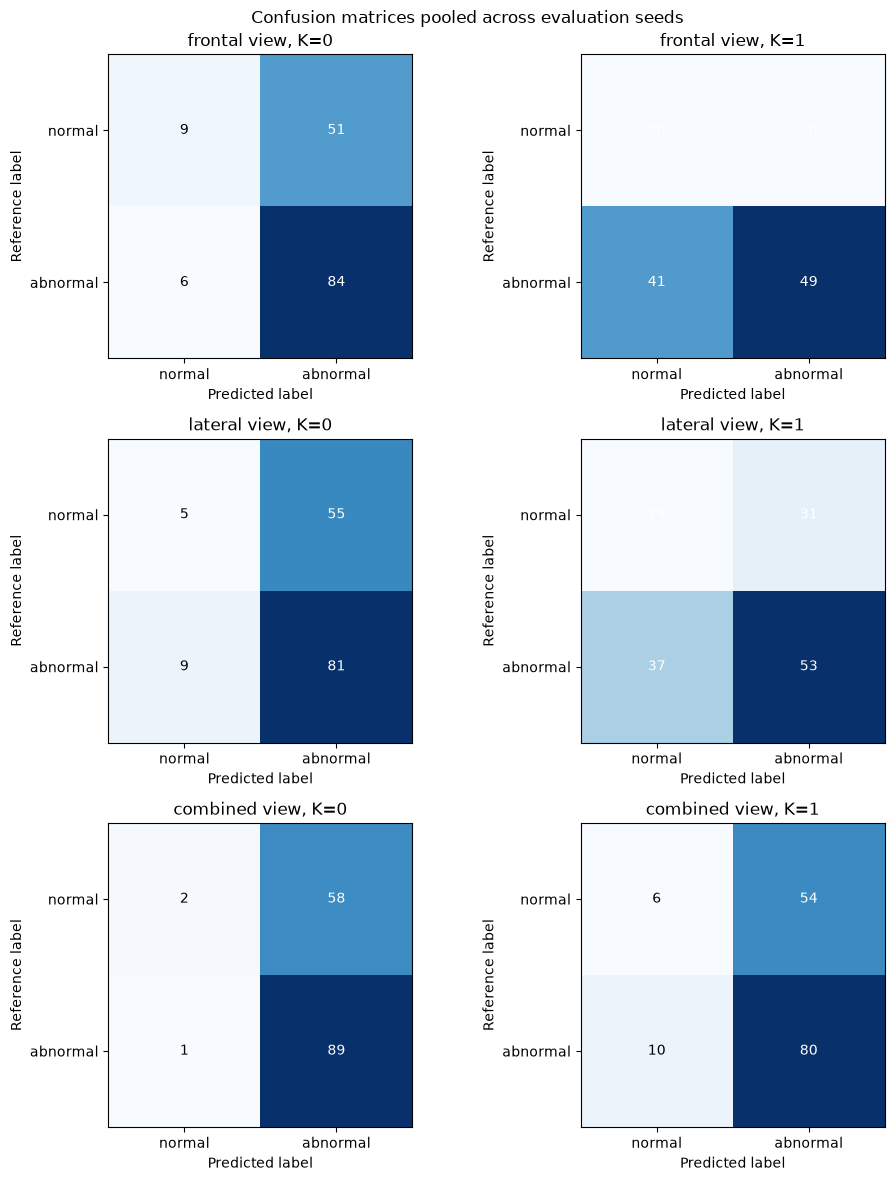

In [14]:
metric_rows = []
for (view, seed, k), group in results.groupby(["view", "seed", "k"]):
    seed_matrix = confusion_matrix(
        group["reference_label"], group["predicted_label"],
        labels=["normal", "abnormal"],
    )
    true_negative, false_positive = seed_matrix[0]
    false_negative, true_positive = seed_matrix[1]
    metric_rows.append({
        "view": view, "seed": seed, "k": k,
        "f1": f1_score(
            group["reference_label"], group["predicted_label"],
            labels=["normal", "abnormal"], average="macro", zero_division=0,
        ),
        "sensitivity": (true_positive / (true_positive + false_negative) if true_positive + false_negative else 0.0),
        "specificity": (true_negative / (true_negative + false_positive) if true_negative + false_positive else 0.0),
        **group[["prompt_tokens", "generated_tokens", "runtime_seconds"]].mean().to_dict(),
    })
metrics = pd.DataFrame(metric_rows)
print(
    metrics.drop(columns="seed")
    .groupby(["view", "k"]).agg(["mean", "std"])
    .reindex(VIEWS, level="view")
    .round(3)
)

cm_labels = ["normal", "abnormal"]
figure, axes = plt.subplots(
    len(VIEWS), 2, figsize=(10, 4 * len(VIEWS)), squeeze=False,
)
for row, view in enumerate(VIEWS):
    for column, k in enumerate(sorted(results["k"].unique())):
        group = results[results["view"].eq(view) & results["k"].eq(k)]
        matrix = confusion_matrix(
            group["reference_label"], group["predicted_label"],
            labels=cm_labels,
        )
        axes[row, column].imshow(matrix, cmap="Blues")
        axes[row, column].set(
            xticks=range(len(cm_labels)), xticklabels=cm_labels,
            yticks=range(len(cm_labels)), yticklabels=cm_labels,
            xlabel="Predicted label", ylabel="Reference label",
            title=f"{view} view, K={k}",
        )
        threshold = matrix.max() / 2 if matrix.size else 0
        for reference_index in range(len(cm_labels)):
            for predicted_index in range(len(cm_labels)):
                axes[row, column].text(
                    predicted_index, reference_index,
                    matrix[reference_index, predicted_index],
                    ha="center", va="center",
                    color="white" if matrix[reference_index, predicted_index] > threshold else "black",
                )
figure.suptitle("Confusion matrices pooled across evaluation seeds")
figure.tight_layout()
plt.show()
